<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/05_sustax_future_projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración e imports**

In [1]:
from google.colab import drive
import os
import glob
import pandas as pd
import numpy as np

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")

BYSCEN_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED", "BY_SCENARIO_TOTAL")

OUT_DIR = os.path.join(SUSTAX_DIR, "FUTURE_EXTREMES")
os.makedirs(OUT_DIR, exist_ok=True)

THRESHOLD = 50  # mm/día

print("BYSCEN_TOTAL_FOLDER:", BYSCEN_TOTAL_FOLDER)
print("OUT_DIR:", OUT_DIR)

Mounted at /content/drive
BYSCEN_TOTAL_FOLDER: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_TOTAL_MERGED/BY_SCENARIO_TOTAL
OUT_DIR: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FUTURE_EXTREMES


# **Detectar eventos extremos**

In [2]:
def normalize_date_series(s):
    return pd.to_datetime(s, errors="coerce").dt.normalize()

def pick_precip_col(df):
    meta_cols = {"sustax_total", "lat", "lon", "date"}
    candidates = [c for c in df.columns if c not in meta_cols]
    return candidates[0]

files = glob.glob(os.path.join(BYSCEN_TOTAL_FOLDER, "*.csv"))

rows = []

for fp in files:
    name = os.path.basename(fp)

    if "summary" in name.lower():
        continue

    parts = name.replace(".csv", "").split("__")
    if len(parts) < 2:
        continue

    sustax_total = parts[0]
    scenario = parts[1]

    df = pd.read_csv(fp)

    if "date" not in df.columns:
        continue

    df["date"] = normalize_date_series(df["date"])
    df = df.dropna(subset=["date"]).copy()

    pp_col = pick_precip_col(df)
    df[pp_col] = pd.to_numeric(df[pp_col], errors="coerce")

    # 🔥 detectar eventos extremos
    extreme = df[df[pp_col] >= THRESHOLD].copy()

    for _, r in extreme.iterrows():
        rows.append({
            "point": sustax_total,
            "scenario": scenario,
            "date": r["date"],
            "year": r["date"].year,
            "month": r["date"].month,
            "precip_mm": r[pp_col]
        })

df_extremes = pd.DataFrame(rows)

print("Eventos detectados:", df_extremes.shape)
display(df_extremes.head())

out_fp = os.path.join(OUT_DIR, "future_extreme_events.csv")
df_extremes.to_csv(out_fp, index=False)

print("Archivo guardado:", out_fp)

Eventos detectados: (13155, 6)


,point,scenario,date,year,month,precip_mm
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,1979-07-08,1979,7,65.077946
1,Sustax_ Manzanillo_LosReyesTotal,SSP119,1980-01-31,1980,1,69.507018
2,Sustax_ Manzanillo_LosReyesTotal,SSP119,1980-07-03,1980,7,63.527733
3,Sustax_ Manzanillo_LosReyesTotal,SSP119,1982-06-26,1982,6,66.217437
4,Sustax_ Manzanillo_LosReyesTotal,SSP119,1982-09-04,1982,9,55.325896


Archivo guardado: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FUTURE_EXTREMES/future_extreme_events.csv


# **Timeline por escenario**

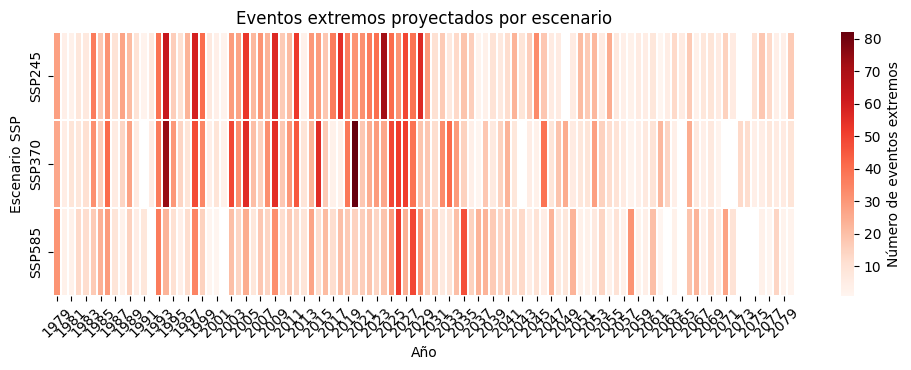

year,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2071,2072,2073,2074,2075,2076,2077,2078,2079,2080
scenario,,,,,,,,,,,,,,,,,,,,,
SSP245,28.0,4.0,3.0,8.0,7.0,37.0,18.0,31.0,10.0,27.0,...,15.0,6.0,NaN,NaN,10.0,18.0,13.0,4.0,4.0,17.0
SSP370,26.0,5.0,9.0,8.0,11.0,32.0,16.0,41.0,6.0,14.0,...,NaN,NaN,13.0,12.0,4.0,5.0,8.0,6.0,6.0,9.0
SSP585,31.0,3.0,3.0,13.0,12.0,17.0,24.0,29.0,9.0,3.0,...,27.0,10.0,NaN,NaN,NaN,3.0,1.0,14.0,2.0,2.0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

SCENARIOS_MAIN = ["SSP245", "SSP370", "SSP585"]

timeline = (
    df_extremes[df_extremes["scenario"].isin(SCENARIOS_MAIN)]
    .groupby(["scenario", "year"])
    .size()
    .reset_index(name="n_events")
)

heat = timeline.pivot(index="scenario", columns="year", values="n_events")

plt.figure(figsize=(10, 3.8))
ax = sns.heatmap(
    heat,
    cmap="Reds",
    linewidths=0.3,
    annot=False,
    cbar_kws={"label": "Número de eventos extremos"}
)

years = list(heat.columns)
step = 2 if len(years) > 10 else 1
ax.set_xticks(np.arange(0.5, len(years), step))
ax.set_xticklabels(years[::step], rotation=45)

plt.title("Eventos extremos proyectados por escenario")
plt.xlabel("Año")
plt.ylabel("Escenario SSP")
plt.tight_layout()
plt.show()

display(heat.head())

# **Timeline por tipo (intensidad)**

/tmp/ipykernel_2128/4107408697.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_extremes.groupby(["event_type", "year"])


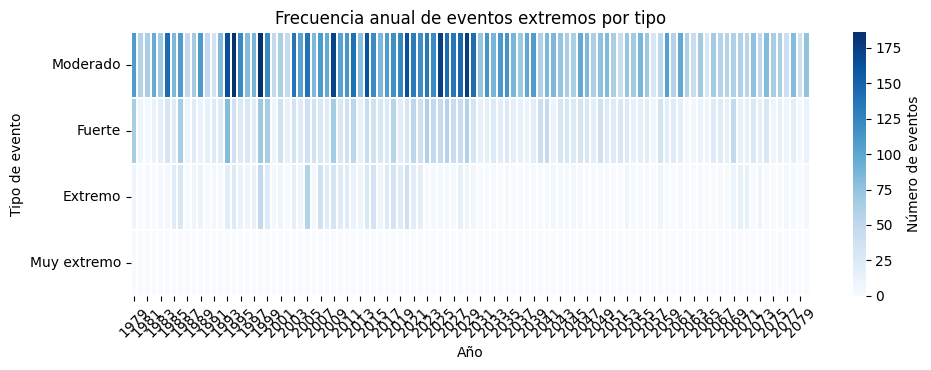

year,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2071,2072,2073,2074,2075,2076,2077,2078,2079,2080
event_type,,,,,,,,,,,,,,,,,,,,,
Moderado,108,58,63,95,68,143,84,108,48,67,...,55,77,50,82,64,63,40,82,38,75
Fuerte,64,9,5,13,17,31,22,65,10,23,...,14,28,17,29,9,15,8,17,5,12
Extremo,9,0,3,1,4,6,23,28,2,9,...,16,1,10,1,0,1,5,3,0,5
Muy extremo,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_extremes["event_type"] = pd.cut(
    df_extremes["precip_mm"],
    bins=[50, 100, 200, 500, np.inf],
    labels=["Moderado", "Fuerte", "Extremo", "Muy extremo"],
    right=False
)

timeline_type = (
    df_extremes.groupby(["event_type", "year"])
    .size()
    .reset_index(name="n_events")
)

heat_type = timeline_type.pivot(index="event_type", columns="year", values="n_events")

plt.figure(figsize=(10, 3.8))
ax = sns.heatmap(
    heat_type,
    cmap="Blues",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Número de eventos"}
)

years = list(heat_type.columns)
step = 2 if len(years) > 10 else 1
ax.set_xticks(np.arange(0.5, len(years), step))
ax.set_xticklabels(years[::step], rotation=45)

plt.title("Frecuencia anual de eventos extremos por tipo")
plt.xlabel("Año")
plt.ylabel("Tipo de evento")
plt.tight_layout()
plt.show()

display(heat_type.head())

# **Eventos por estación**

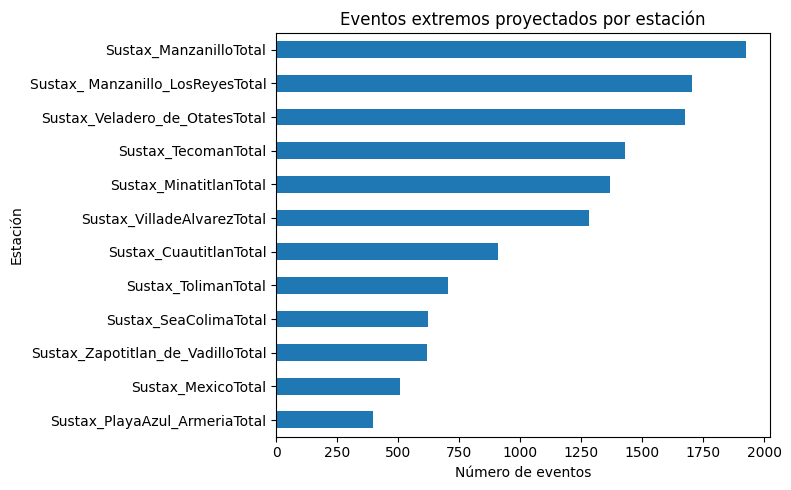

,n_events
point,
Sustax_PlayaAzul_ArmeriaTotal,399
Sustax_MexicoTotal,508
Sustax_Zapotitlan_de_VadilloTotal,620
Sustax_SeaColimaTotal,623
Sustax_TolimanTotal,705


In [10]:
station_counts = (
    df_extremes.groupby("point")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
station_counts.plot(kind="barh")

plt.title("Eventos extremos proyectados por estación")
plt.xlabel("Número de eventos")
plt.ylabel("Estación")
plt.tight_layout()
plt.show()

display(station_counts.to_frame("n_events").head())

# **Distribución mensual**

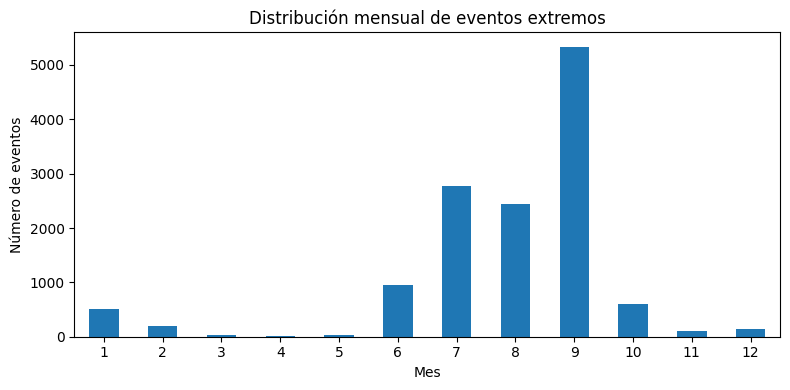

,n_events
month,
1,517
2,199
3,37
4,11
5,35
6,958
7,2770
8,2443
9,5333


In [11]:
month_counts = (
    df_extremes.groupby("month")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

plt.figure(figsize=(8, 4))
month_counts.plot(kind="bar")

plt.title("Distribución mensual de eventos extremos")
plt.xlabel("Mes")
plt.ylabel("Número de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(month_counts.to_frame("n_events").head(12))